# Evaluating the Trained Channel Estimator

Now that we have a trained model, we can use it inside the communication pipeline and compare its performance with two baselines: perfect channel knowledge and **NeoRadium**'s least-squares (LS) channel estimation with interpolation.

The goal of this notebook is to provide a simple end-to-end tutorial, not a complete system-level benchmark. Therefore, the evaluation uses one representative channel and link configuration. This makes the comparison easy to reproduce and interpret, while the training dataset from the previous notebooks still exposes the model to a wider range of CDL profiles and channel parameters.

The following diagram shows the pipeline used to evaluate the deep-learning-based channel estimator.

![Evaluation-Pipeline](EvalPipeline.png)

Let's start by importing the required modules.

In [1]:
import numpy as np
import scipy.io
import time
import matplotlib.pyplot as plt

from neoradium import BandwidthPart, PDSCH, CdlChannel, AntennaPanel, Grid, random

import torch
from torch import nn

In [2]:
# ----------------------------------------------------------------------------------------------------------------------
# Define the residual block
class ResBlock(nn.Module):
    # ------------------------------------------------------------------------------------------------------------------
    def __init__(self, inDepth, midDepth, outDepth, kernel=(3,3), stride=(1,1)):
        super().__init__()
        if isinstance(stride, int): stride = (stride, stride)
        if isinstance(kernel, int): kernel = (kernel, kernel)

        self.path1 = nn.Sequential(
            nn.Conv2d(inDepth, midDepth, 1, stride, padding='valid'),  # 1x1 conv.
            nn.BatchNorm2d(midDepth),
            nn.ReLU(True),
            nn.Conv2d(midDepth, midDepth, kernel, padding='same'),
            nn.BatchNorm2d(midDepth),
            nn.ReLU(True),
            nn.Conv2d(midDepth, outDepth, 1, padding='valid'), # 1x1 conv.
            nn.BatchNorm2d(outDepth))
        
        self.path2 = None
        if ((stride != (1,1)) or (inDepth!=outDepth)):
            self.path2 = nn.Sequential(nn.Conv2d(inDepth, outDepth, 1, stride),  # 1x1 conv.
                                       nn.BatchNorm2d(outDepth) )

    # ------------------------------------------------------------------------------------------------------------------
    def forward(self, x):
        out = (self.path1(x) + x) if self.path2 is None else (self.path1(x) + self.path2(x))
        out = nn.ReLU(True)(out)
        return out

# ----------------------------------------------------------------------------------------------------------------------
# Define the ChEstNet model
class ChEstNet(nn.Module):
    # ------------------------------------------------------------------------------------------------------------------
    def __init__(self, device):
        super().__init__()
        self.inShape = (6, 14, 288)
        self.res1 = ResBlock(6, 48, 192, (9,9))     # Residual block with a 9x9 kernel
        self.res2 = ResBlock(192, 48, 192, (7,7))   # Residual block with a 7x7 kernel
        self.res3 = ResBlock(192, 48, 192, (3,3))   # Residual block with a 3x3 kernel
        self.conv = nn.Conv2d(192, 4, 3, padding='same')
        self.to(device)

    # ------------------------------------------------------------------------------------------------------------------
    def forward(self, x):
        out = self.res1(x)
        out = self.res2(out)
        out = self.res3(out)
        out = self.conv(out)
        return out

    @property
    def device(self):       return next(self.parameters()).device

    # ------------------------------------------------------------------------------------------------------------------
    def infer(self, samples, toNumpy=True):
        self.eval()  # Set the model to evaluation mode
        if type(samples) is np.ndarray: samples = torch.from_numpy(samples)
        with torch.no_grad():
            if toNumpy: return self(samples.to(self.device)).cpu().numpy()
            return self(samples.to(self.device))

    # ------------------------------------------------------------------------------------------------------------------
    def loadParams(self, fileName):
        if type(fileName)==str:
            self.load_state_dict( torch.load(fileName, weights_only=True, map_location=self.device) )
        else:
            self.load_state_dict(fileName)


## Loading the Trained Model

Here we define the channel-estimator model and initialize it with the trained parameters saved during training.

For clarity, the model definition is repeated in this notebook. In a cleaned-up project or reusable package example, this definition should be moved to a shared Python module and imported by both the training and evaluation notebooks. That avoids accidental differences between the architecture used for training and the architecture used for evaluation.

In [3]:
# Check GPU availability
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("Using the '%s' device."%({'cuda':'Cuda', 'mps':'Metal','cpu':'CPU'}[device]))

# Instantiate the model and move it to the target device
model = ChEstNet(device)

# Load the trained model parameters
model.loadParams('Models/ChEstModelWeights.pth');
model.eval();  # Set the model to evaluation mode


Using the 'Cuda' device.


## The `mlChanEst` Function

The `mlChanEst` function below receives a PDSCH object, the received resource grid, and the trained model. It uses the model to estimate the effective channel for each receive antenna and then combines the per-antenna predictions into a 4-D `L x K x Nr x Nl` effective channel matrix.

This ML estimator returns the channel estimate only. By contrast, **NeoRadium**'s LS estimator also returns an error-variance estimate that can be used by the equalizer. In this tutorial, we keep the ML interface simple and pass only the predicted channel to the receiver. This is sufficient for demonstrating the channel-estimation workflow and BER comparison, but a more complete receiver could also estimate an ML-based error variance, for example from the DMRS residuals.

In [4]:
def mlChanEst(pdsch, rxGrid, model):
    dmrsIdx = pdsch.grid.getReIndexes("DMRS")   # This contains the locations of DMRS values
    rr, ll, kk = rxGrid.shape                   # Number of RX antennas, symbols, and subcarriers

    ls = np.unique(dmrsIdx[1])                                                  # Unique DMRS symbols
    ks = np.unique(dmrsIdx[2])                                                  # Unique DMRS subcarriers
    samples = np.zeros( (rr, pdsch.numLayers+1, ll, kk), dtype=np.complex128)   # Nr x Nl+1 x L x K
    for r in range(rr):
        samples[r][dmrsIdx] = pdsch.grid[dmrsIdx]                               # Known DMRS values
        samples[r][np.ix_([-1], ls, ks)] = rxGrid[ np.ix_([r], ls, ks) ]        # Received grid values at DMRS 
                                                                                # symbol/subcarrier locations

    samples = np.concatenate([samples.real, samples.imag],axis=1)               # Nr x 2(Nl+1) x L x K
    predChan = model.infer(np.float32(samples))                                 # Nr x 2Nl x L x K   (float32)
    predChan = predChan[:,:pdsch.numLayers] + 1j*predChan[:,pdsch.numLayers:]   # Nr x Nl x L x K    (complex-valued)
    return np.transpose(predChan, [2,3,0,1])

## Evaluation Pipeline

The following cell implements the evaluation pipeline shown above. It runs the simulation three times, using perfect channel knowledge, the ML channel estimator, and the LS channel estimator. The BER results are printed at the end.

The ML estimator is compared with LS interpolation in a fixed tutorial configuration. This is not intended to be an exhaustive generalization study across every channel profile, mobility value, bandwidth, or DMRS pattern. The dataset-level test evaluation in the training notebook provides an additional check on generalization across held-out data.

Also note that the precoder is computed from the true channel for all three methods. This isolates the receiver-side channel-estimation problem and keeps the transmitted signals identical across the comparison. A more realistic closed-loop simulation could use practical transmitter-side CSI or a fixed/codebook precoder, but that would add complexity beyond the scope of this introductory example.


Running the end-to-end simulation for "Perfect" channel estimation, in frequency domain.
SNR(dB)   Total Bits   Bit Errors   BER(%)   time(sec.)
-------   ----------   ----------   ------   ----------
  -20     14,400,000   5,425,510    37.68      43.65   
  -15     14,400,000   4,162,364    28.91      44.77   
  -10     14,400,000   2,643,504    18.36      42.21   
  -5      14,400,000   1,305,900     9.07      43.79   
   0      14,400,000   483,837       3.36      44.58   
   5      14,400,000   102,615       0.71      42.69   
  10      14,400,000   11,731        0.08      42.31   

Running the end-to-end simulation for "ML" channel estimation, in frequency domain.
SNR(dB)   Total Bits   Bit Errors   BER(%)   time(sec.)
-------   ----------   ----------   ------   ----------
  -20     14,400,000   5,577,078    38.73      43.16   
  -15     14,400,000   4,279,984    29.72      43.30   
  -10     14,400,000   2,759,149    19.16      43.24   
  -5      14,400,000   1,406,787     9.77

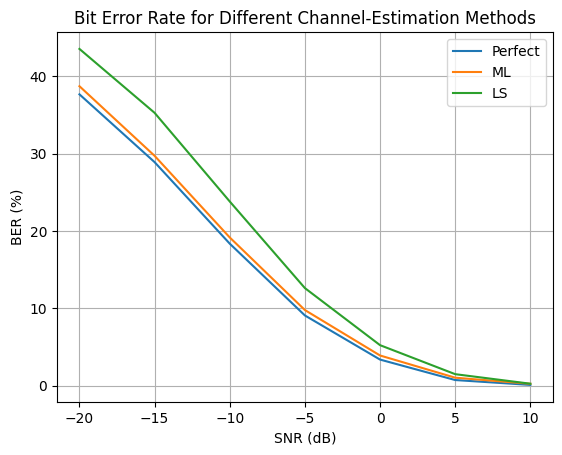

In [5]:
numSlots = 500                      # Number of slots
snrDbs = range(-20,11,5)            # SNR values, in dB, used to evaluate the model

bwp = BandwidthPart(numRbs=24, spacing=15)  # Bandwidth part object with 24 PRBs and 15 kHz subcarrier spacing

pdsch = PDSCH(bwp, numLayers=2, modulation="16QAM")     # Create a PDSCH object
pdsch.setDMRS(configType=1, additionalPos=2)            # Specify the DMRS configuration
results = {}                                            # Dictionary used to store the results

for chanEstMethod in ["Perfect", "ML", "LS"]:           # Three channel-estimation methods
    results[chanEstMethod] = {}
    print(f"\nRunning the end-to-end simulation for \"{chanEstMethod}\" channel estimation, in frequency domain.")
    print("SNR(dB)   Total Bits   Bit Errors   BER(%)   time(sec.)")
    print("-------   ----------   ----------   ------   ----------")
    for snrDb in snrDbs:                                # For each SNR value in snrDbs
        random.setSeed(123)                             # Make the results reproducible for each SNR
        t0 = time.monotonic()                           # Start time for each SNR

        # Create a CdlChannel object
        channel = CdlChannel(bwp, 'C', delaySpread=300, carrierFreq=4e9, dopplerShift=5,
                             txAntenna=AntennaPanel([2,2], polarization="x"),  # 8 TX antennas
                             rxAntenna=AntennaPanel([1,1], polarization="x"),  # 2 RX antennas
                             seed = 123)  

        bitErrors = 0
        totalBits = 0

        for slotNo in range(numSlots):
            pdsch.initGrid()                                    # Create and initialize PDSCH's internal grid
            numBits = pdsch.getBitCapacity()[0]                 # Number of bits available in the resource grid
            txBits = random.bits(numBits)                       # Create random binary data
            pdsch.setPdschData(txBits)                          # Map/modulate the data to the resource grid

            channelMatrix = channel.getChannelMatrix()          # Get the channel matrix
            precoder = pdsch.getPrecodingMatrix(channelMatrix)  # Get the precoder matrix from the PDSCH object
         
            txGrid = bwp.createGrid(channelMatrix.shape[3])     # Create the transmitted grid
            pdsch.precodeTo(txGrid, precoder)                   # Perform the precoding

            rxGrid = txGrid.applyChannel(channelMatrix)         # Apply the channel in the frequency domain
            rxGrid = rxGrid.addNoise(snrDb=snrDb)               # Add noise

            errVar = None                                       # Used only with LS channel estimation
            if chanEstMethod == "Perfect":                      # Perfect channel knowledge
                estChannelMatrix = CdlChannel.getEffChannel(channelMatrix, precoder)  # Ground-truth channel
            elif chanEstMethod == "LS":                         # LS + interpolation channel estimation
                estChannelMatrix, errVar = pdsch.estimateChannel(rxGrid)
            elif chanEstMethod == "ML":                         # ML-based channel estimation
                estChannelMatrix = mlChanEst(pdsch, rxGrid, model)
            else: assert(0)

            eqGrid, llrScales = pdsch.equalize(rxGrid, estChannelMatrix, errVar)    # Equalization
            rxBits = pdsch.getHardBits(eqGrid)[0]               # Demodulation (hard decision)
            bitErrors += np.abs(rxBits-txBits).sum()            # Calculate the number of bit errors
            totalBits += numBits
            print(f"{snrDb:^7d}   {totalBits:<10,d}   {bitErrors:<10,d}   {bitErrors*100/totalBits:^6.2f}"
                  f"   {time.monotonic()-t0:^10.2f}", end='\r') 
            channel.goNext()                                    # Prepare the channel model for the next slot

        dt = time.monotonic()-t0                                # Total time for this SNR
        results[chanEstMethod][snrDb] = {"totalBits":totalBits, 
                                         "bitErrors":bitErrors, 
                                         "BER":      bitErrors*100/totalBits,
                                         "Time":     dt}
        print()
    
# Plot the results
for i,chanEstMethod in enumerate(['Perfect', 'ML', 'LS']):
    bers = [results[chanEstMethod][snrDb]["BER"] for snrDb in snrDbs]
    plt.plot(snrDbs, bers, label=chanEstMethod)
plt.legend()
plt.title("Bit Error Rate for Different Channel-Estimation Methods")
plt.grid()
plt.xlabel("SNR (dB)")
plt.xticks(snrDbs)
plt.ylabel("BER (%)")
plt.show()